In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [29]:
# 1. Load dataset
df = pd.read_csv("indian_certificate_dataset.csv")

In [30]:
# 2. Feature Engineering: Efficiency Score
df["Efficiency_Score"] = (
    df["Applications_Processed_This_Month"] /
    (df["No_of_Staff"] * df["Office_Working_Hours_Per_Week"])
) * (1 / df["Average_Processing_Time_Mins"])

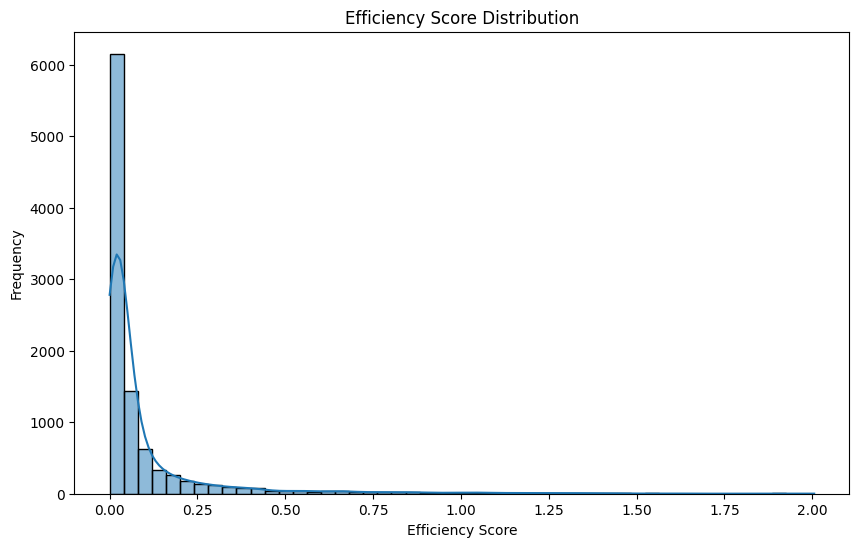

In [31]:
# ==========================
# 📊 START: Data Analysis
# ==========================
plt.figure(figsize=(10, 6))
sns.histplot(df["Efficiency_Score"], bins=50, kde=True)
plt.title("Efficiency Score Distribution")
plt.xlabel("Efficiency Score")
plt.ylabel("Frequency")
plt.show()

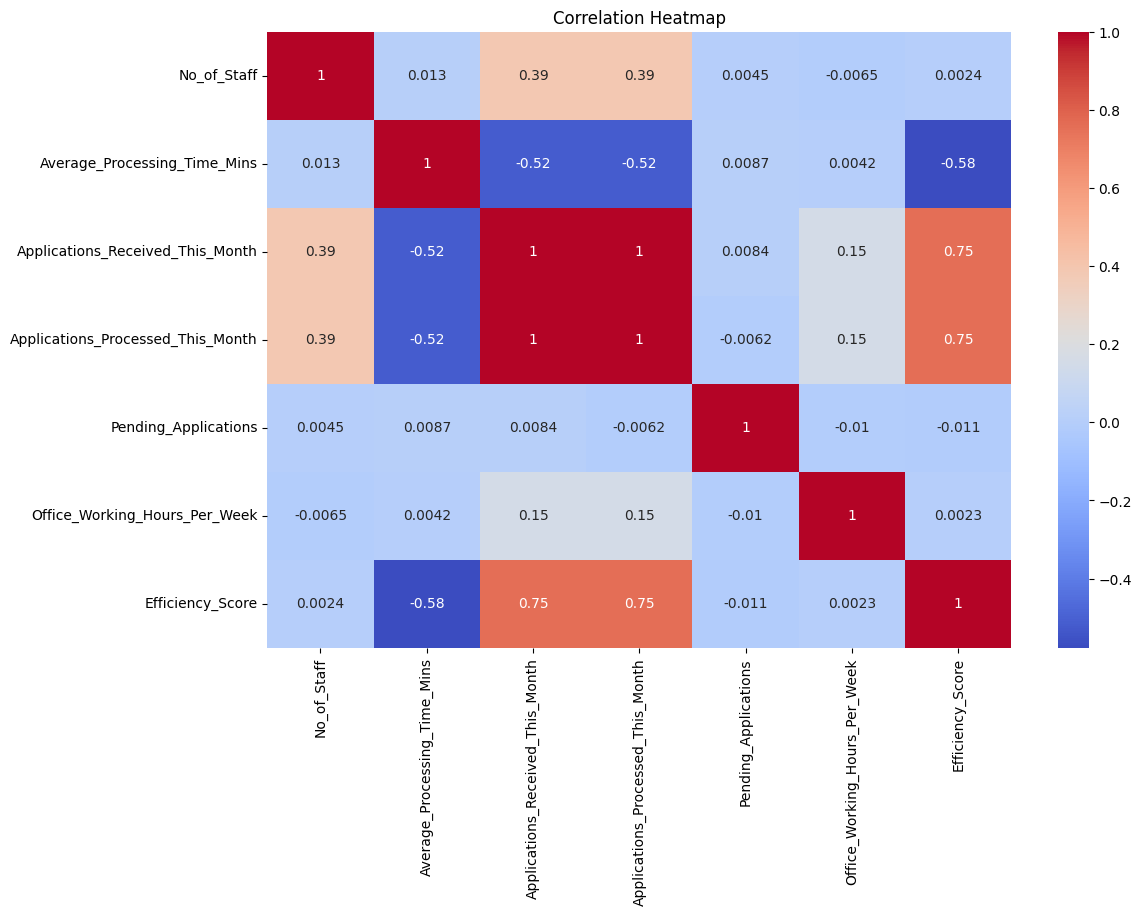

In [32]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
# 3. Encode Categorical Features
label_encoders = {}
for col in ["Office_ID", "Location", "Certificate_Type"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [46]:
# 4. Feature Columns
features = [
    "Office_ID", "Location", "Certificate_Type", "No_of_Staff",
    "Average_Processing_Time_Mins", "Applications_Received_This_Month",
    "Applications_Processed_This_Month", "Pending_Applications",
    "Office_Working_Hours_Per_Week"
]
X = df[features].values
y = df["Efficiency_Score"].values

In [35]:
# 5. Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [36]:
# 6. Split data (Train 70%, Val 15%, Test 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

In [37]:
# 7. Create Dataset class
class OfficeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = OfficeDataset(X_train, y_train)
val_dataset = OfficeDataset(X_val, y_val)
test_dataset = OfficeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [38]:
# 8. Define Neural Network
class EfficiencyModel(nn.Module):
    def __init__(self, input_dim):
        super(EfficiencyModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [39]:
# 9. Initialize Model
model = EfficiencyModel(input_dim=X.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
# 10. Train Model with Validation and collect loss
train_losses, val_losses = [], []

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_preds = model(X_batch)
                val_loss += criterion(val_preds, y_batch).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

train_model(model, train_loader, val_loader, criterion, optimizer)

Epoch 1/20, Train Loss: 0.9335, Val Loss: 0.0146
Epoch 2/20, Train Loss: 0.1480, Val Loss: 0.0124
Epoch 3/20, Train Loss: 0.0799, Val Loss: 0.0061
Epoch 4/20, Train Loss: 0.0499, Val Loss: 0.0049
Epoch 5/20, Train Loss: 0.0339, Val Loss: 0.0034
Epoch 6/20, Train Loss: 0.0228, Val Loss: 0.0025
Epoch 7/20, Train Loss: 0.0158, Val Loss: 0.0020
Epoch 8/20, Train Loss: 0.0122, Val Loss: 0.0021
Epoch 9/20, Train Loss: 0.0096, Val Loss: 0.0016
Epoch 10/20, Train Loss: 0.0087, Val Loss: 0.0014
Epoch 11/20, Train Loss: 0.0074, Val Loss: 0.0012
Epoch 12/20, Train Loss: 0.0067, Val Loss: 0.0011
Epoch 13/20, Train Loss: 0.0064, Val Loss: 0.0011
Epoch 14/20, Train Loss: 0.0054, Val Loss: 0.0009
Epoch 15/20, Train Loss: 0.0054, Val Loss: 0.0008
Epoch 16/20, Train Loss: 0.0052, Val Loss: 0.0009
Epoch 17/20, Train Loss: 0.0048, Val Loss: 0.0009
Epoch 18/20, Train Loss: 0.0042, Val Loss: 0.0008
Epoch 19/20, Train Loss: 0.0046, Val Loss: 0.0009
Epoch 20/20, Train Loss: 0.0041, Val Loss: 0.0009


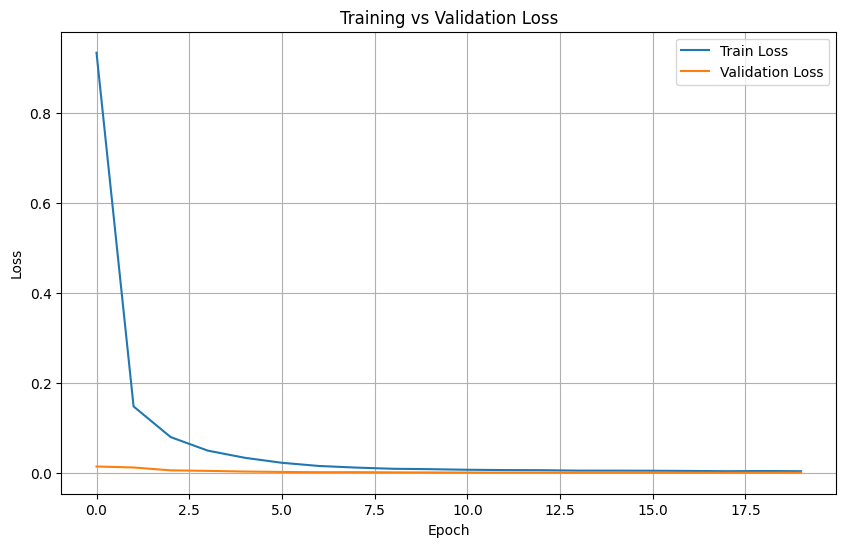

In [40]:
# ==========================
# 📈 MID: Training Analysis
# ==========================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# 11. Evaluate Model on Test Set
def evaluate_model(model, test_loader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            predictions.extend(preds.numpy())
            actuals.extend(y_batch.numpy())
    return np.array(predictions), np.array(actuals)

predictions, actuals = evaluate_model(model, test_loader)


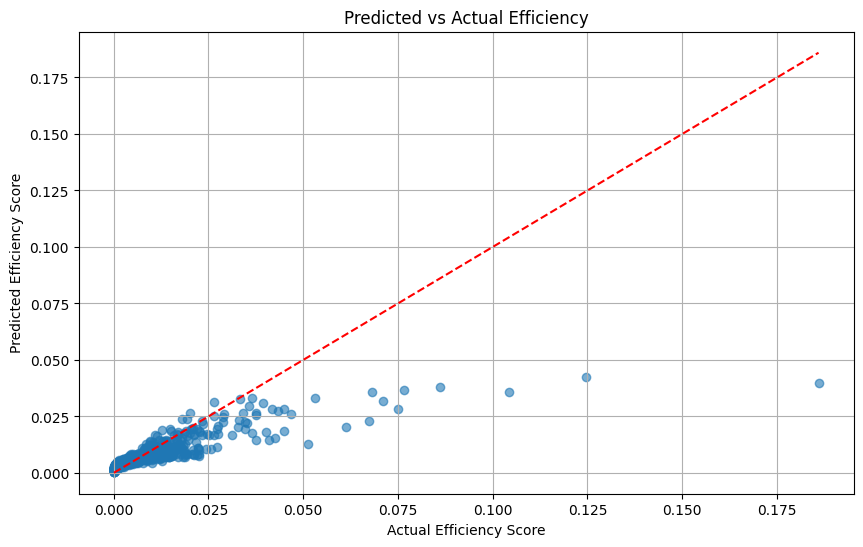


Sample Predictions:
Predicted: 0.0043, Actual: 0.0034
Predicted: 0.0118, Actual: 0.0142
Predicted: 0.0054, Actual: 0.0056
Predicted: 0.0024, Actual: 0.0005
Predicted: 0.0112, Actual: 0.0118


In [21]:
# ==========================
# 📉 END: Final Evaluation
# ==========================
plt.figure(figsize=(10, 6))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')
plt.xlabel("Actual Efficiency Score")
plt.ylabel("Predicted Efficiency Score")
plt.title("Predicted vs Actual Efficiency")
plt.grid(True)
plt.show()

# Print few examples
print("\nSample Predictions:")
for i in range(5):
    print(f"Predicted: {predictions[i][0]:.4f}, Actual: {actuals[i][0]:.4f}")